In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy as sc
import statsmodels.formula.api as smf
from statsmodels.regression.mixed_linear_model import MixedLMResults
import os
import warnings
from scipy import stats
from pathlib import Path
from statsmodels.tools.sm_exceptions import ConvergenceWarning
os.makedirs('plots', exist_ok=True)
base_dir = Path(".")
sns.set_theme(style='ticks', palette='pastel')
task_colors = ['xkcd:sky blue', 'xkcd:peach', 'xkcd:light olive', 'xkcd:lavender']
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter('ignore', ConvergenceWarning)

if (base_dir / "df_performance.csv").exists() and (base_dir / "df_performance.csv").exists() and (base_dir / "df_performance.csv").exists() and (base_dir / "df_performance.csv").exists():
    print('CSV files existing. No need to run preprocessing. Loading...')
    df_performance = pd.read_csv(base_dir / "df_performance.csv", index_col=['name', 'task', 'phase'])
    df_sketch = pd.read_csv(base_dir / "df_sketch.csv", index_col=['task', 'landmark', 'on_turn'])
    df_fixations = pd.read_csv(base_dir / "df_fixations.csv", index_col=['name', 'task', 'aoi', 'iface'])
    df_general = pd.read_csv(base_dir / "df_general.csv", index_col=['name'])
else:
    raise SystemError

CSV files existing. No need to run preprocessing. Loading...


---

In [2]:

# ============================================================================
# FUNCTION 1: Likelihood Ratio Test
# ============================================================================

def likelihood_ratio_test(model_simple, model_complex):
    """
    Compare two nested models using Likelihood Ratio Test.
    
    Parameters:
    -----------
    model_simple : fitted MixedLM model
        The simpler model (fewer parameters)
    model_complex : fitted MixedLM model
        The more complex model (more parameters)
    
    Returns:
    --------
    dict with LR statistic, degrees of freedom, p-value, and significance
    """
    # Get log-likelihoods from both models
    llf_simple = model_simple.llf    # How well simple model fits data
    llf_complex = model_complex.llf  # How well complex model fits data
    
    # Calculate how many extra parameters the complex model has
    df_diff = len(model_complex.params) - len(model_simple.params)
    
    # LR statistic: 2 × (improvement in log-likelihood)
    # This follows a chi-squared distribution with df_diff degrees of freedom
    lr_stat = 2 * (llf_complex - llf_simple)
    
    # Calculate p-value: probability of getting this LR if null hypothesis is true
    # (null = extra parameters don't help)
    p_value = stats.chi2.sf(lr_stat, df_diff)
    
    # Create significance label for easy interpretation
    if p_value < 0.001:
        sig = '***'
    elif p_value < 0.01:
        sig = '**'
    elif p_value < 0.05:
        sig = '*'
    else:
        sig = 'ns'  # not significant
    
    return {
        'LR': lr_stat,
        'df': df_diff,
        'p': p_value,
        'sig': sig
    }


# ============================================================================
# FUNCTION 2: Fit model hierarchy and select best via LRT
# ============================================================================

def fit_model_hierarchy(df, var):
    """
    Fit models in increasing complexity, use LRT to decide when to stop.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Your data with columns for participant, interface, task, and var
    var : str
        Name of dependent variable (e.g., 'phase1_time')
    
    Returns:
    --------
    dict with all fitted models and the selected best model
    """
    
    # Print header
    print(f"\n{'='*70}")
    print(f"Analyzing: {var}")
    print(f"{'='*70}\n")
    
    # Define the 4 models we'll test, in order of complexity
    models = [
        {
            'name': 'M1: Iface only ~1',
            # Fixed effect: just interface (lf vs tbt)
            # Random effect: intercept per participant (~1)
            'formula': f'{var} ~ C(iface)',
            're_formula': '~1'
        },
        {
            'name': 'M2: Iface + Task ~1 (adding task)',
            # Fixed effects: interface + task (additive, no interaction)
            # Random effect: still just intercept
            'formula': f'{var} ~ C(iface) + C(task)',
            're_formula': '~1'
        },
        {
            'name': 'M3: Iface * Task ~1 (studying interaction)',
            # Fixed effects: interface * task (includes main effects + interaction)
            # This tests if interface effect changes across tasks
            # Random effect: still just intercept
            'formula': f'{var} ~ C(iface) * C(task)',
            're_formula': '~1'
        },
        {
            'name': 'M4: Iface * Task ~(1 | C(Iface)) (adding random slope for iface)',
            # Fixed effects: same as M3 (interface * task)
            # Random effects: intercept + slope for interface
            # This allows each participant to have their own interface effect
            'formula': f'{var} ~ C(iface) * C(task)',
            're_formula': f'~C(iface)'
        }
    ]
    
    fitted_models = []
    
    print("Fitting models with ML (for comparison)...")
    for spec in models:
        try:
            # Create the model object
            # groups= specifies which observations belong to same participant
            model = smf.mixedlm(
                spec['formula'],
                df,
                groups=df['name'],          # Grouping by participant
                re_formula=spec['re_formula'] # Random effects formula
            )
            
            # Fit the model
            # reml=False means use ML (for comparison)
            # method='lbfgs' is optimization algorithm (more robust)
            # maxiter=1000 gives it enough iterations to converge
            fitted = model.fit(reml=False, method='lbfgs', maxiter=1000)
            
            # Store the fitted model
            fitted_models.append({
                'name': spec['name'],
                'fitted': fitted,
                'formula': spec['formula'],
                're_formula': spec['re_formula'],
                'converged': fitted.converged
            })
            conv_status = "✓" if fitted.converged else "⚠"
            print(f"  {conv_status} {spec['name']}")
            
        except Exception as e:
            # If model fails to fit, print error and store None
            print(f"  ✗ {spec['name']} failed: {e}")
            fitted_models.append(None)
    
     # Compare ALL pairs
    print(f"\n{'='*70}")
    print("Likelihood Ratio Tests (all comparisons)")
    print(f"{'='*70}")
    
    comparisons = [
        (0, 1, "M1 vs M2: Does task matter?"),
        (1, 2, "M2 vs M3: Is there interaction?"),
        (2, 3, "M3 vs M4: Random slopes needed?"),
        (0, 2, "M1 vs M3: Does task+interaction matter?"),  # Direct comparison!
    ]
    
    lrt_results = []
    for idx_simple, idx_complex, description in comparisons:
        if fitted_models[idx_simple] is None or fitted_models[idx_complex] is None:
            continue
        
        simple = fitted_models[idx_simple]['fitted']
        complex = fitted_models[idx_complex]['fitted']
        
        lrt = likelihood_ratio_test(simple, complex)
        lrt_results.append({
            'comparison': description,
            'LR': lrt['LR'],
            'df': lrt['df'],
            'p': lrt['p'],
            'sig': lrt['sig']
        })
        
        print(f"\n{description}")
        print(f"  LR χ²({lrt['df']}) = {lrt['LR']:.2f}, p = {lrt['p']:.4f} {lrt['sig']}")
    
    # Decision logic: prioritize interaction test
    print(f"\n{'='*70}")
    print("Model selection")
    print(f"{'='*70}")
    
    # Check M1 vs M3 first (interaction)
    m1_vs_m3 = [r for r in lrt_results if 'M1 vs M3' in r['comparison']]
    if m1_vs_m3 and m1_vs_m3[0]['p'] < 0.05:
        print(f"\n✓ M1 vs M3 is significant (p={m1_vs_m3[0]['p']:.4f})")
        print(f"  → Interaction model (M3) is justified")
        
        # Check if M4 improves over M3
        m3_vs_m4 = [r for r in lrt_results if 'M3 vs M4' in r['comparison']]
        if m3_vs_m4 and m3_vs_m4[0]['p'] < 0.05:
            best_idx = 3
            print(f"  → M4 (random slopes) further improves fit")
        else:
            best_idx = 2
            print(f"  → M3 is adequate (random slopes not needed)")
    else:
        # Fall back to sequential logic
        m1_vs_m2 = [r for r in lrt_results if 'M1 vs M2' in r['comparison']]
        if m1_vs_m2 and m1_vs_m2[0]['p'] < 0.05:
            best_idx = 1
            print(f"\n✓ M2 (additive) is better than M1")
        else:
            best_idx = 0
            print(f"\n✓ M1 (interface only) is adequate")
    
    best = fitted_models[best_idx]
    print(f"\nSelected: {best['name']}")
    
    # Refit the selected model with REML for final parameter estimates
    # REML gives less biased variance estimates (but can't be used for comparison)
    print("\nRefitting selected model with REML for final estimates...")
    model_reml = smf.mixedlm(
        best['formula'], 
        df, 
        groups=df['name'],
        re_formula=best['re_formula']
    )
    # Now use reml=True for final fit
    final = model_reml.fit(reml=True, method='lbfgs', maxiter=1000)
    
    # Print the final model summary
    print("\n" + "="*70)
    print("FINAL MODEL SUMMARY (REML)")
    print("="*70)
    print(final.summary())
    
    # Return everything
    return {
        'all_models': fitted_models,       # All 4 models (for inspection)
        'best_model': final,               # Selected model with REML
        'best_model_name': best['name'],   # Name of selected model
        'lrt_results': lrt_results
    }


# ============================================================================
# FUNCTION 3: Plot model predictions
# ============================================================================

def plot_final_model(df, fitted_model, var, save_path=None):
    """
    Plot raw data and model predictions.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Your raw data
    fitted_model : fitted MixedLM model
        The final selected model (with REML)
    var : str
        Name of dependent variable
    save_path : str, optional
        Where to save the plot (e.g., 'plots/phase1_time.png')
    
    Returns:
    --------
    matplotlib Figure object
    """
    
    # Create prediction grid: all combinations of interface × task
    grid = pd.DataFrame([
        {'iface': iface, 'task': task}
        for iface in df['iface'].unique()
        for task in sorted(df['task'].unique())
    ])
    
    # Generate predictions from the model
    grid['predicted'] = fitted_model.predict(grid)
    grid['task'] = grid['task'].astype(str)
    df['task'] = df['task'].astype(str)
    
    # Create plot
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    # Plot raw data as individual points (jittered)
    sns.stripplot(
        data=df,           # Your raw data
        x='task',        # x-axis: task difficulty
        y=var,              # y-axis: dependent variable
        hue='iface', # Color by interface
        alpha=0.3,         # Make points transparent
        dodge=True,        # Separate by interface
        ax=ax,             # Plot on this axis
        size=4,            # Point size
        legend=False,      # Don't duplicate legend
    )
    
    # Plot model predictions as lines
    sns.lineplot(
        data=grid,         # Prediction grid we created
        x='task',        # x-axis: task
        y='predicted',     # y-axis: model predictions
        hue='iface', # Color by interface
        marker='o',        # Show points on line
        markersize=10,     # Size of points
        linewidth=3,       # Thickness of line
        ax=ax              # Plot on same axis
    )

    
    # ax.set_xticks([1,2,3,4], ['1','2','3','4'])
    # Labels and styling
    ax.set_xlabel('Task', fontsize=12)
    ax.set_ylabel(var, fontsize=12)
    ax.set_title(f'Model predictions: {var}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)  # Add grid
    
    # Make layout tight
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Saved: {save_path}")
    
    return fig

def plot_diagnostics_final(model, dv_name, model_name="Final model"):
    """
    Diagnostics for one fitted MixedLM model:
    - Residuals vs Fitted
    - QQ-plot
    - Scale-Location
    - Caterpillar plot of random intercepts
    """
    resid = model.resid
    fitted = model.fittedvalues

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # 1) Residuals vs Fitted
    ax = axes[0, 0]
    ax.scatter(fitted, resid, alpha=0.6, s=30, edgecolors='k', linewidths=0.5)
    ax.axhline(0, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("Residuals")
    ax.set_title("Residuals vs Fitted")
    ax.grid(True, alpha=0.3)

    # 2) QQ-Plot of residuals
    ax = axes[0, 1]
    stats.probplot(resid, dist="norm", plot=ax)
    ax.set_title("Q-Q Plot of residuals")
    ax.grid(True, alpha=0.3)

    # 3) Scale-Location (sqrt|standardized residuals|)
    ax = axes[1, 0]
    std_resid = (resid - np.mean(resid)) / np.std(resid)
    sqrt_abs = np.sqrt(np.abs(std_resid))
    ax.scatter(fitted, sqrt_abs, alpha=0.6, s=30, edgecolors='k', linewidths=0.5)
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("√|standardized residuals|")
    ax.set_title("Scale-Location")
    ax.grid(True, alpha=0.3)

    # 4) Caterpillar plot of random intercepts
    ax = axes[1, 1]
    try:
        re = model.random_effects  # dict: group_id -> Series
        intercepts = [v.iloc[0] for v in re.values()]
        names = list(re.keys())

        order = np.argsort(intercepts)
        intercepts_sorted = np.array(intercepts)[order]
        names_sorted = np.array(names)[order]

        # crude CI: same SE for all, just to visualize
        se = np.std(intercepts_sorted) / np.sqrt(len(intercepts_sorted))
        ci_low = intercepts_sorted - 1.96 * se
        ci_high = intercepts_sorted + 1.96 * se
        y = np.arange(len(intercepts_sorted))

        ax.errorbar(intercepts_sorted, y,
                    xerr=[intercepts_sorted - ci_low,
                          ci_high - intercepts_sorted],
                    fmt='o', capsize=3, color='steelblue')
        ax.axvline(0, color='red', linestyle='--', linewidth=2)
        ax.set_yticks([])
        ax.set_xlabel("Random intercept")
        ax.set_title("Caterpillar plot (participants)")
        ax.grid(True, alpha=0.3)
    except Exception as e:
        ax.text(0.5, 0.5, f"Random effects plot failed:\n{e}",
                ha="center", va="center", transform=ax.transAxes)

    plt.suptitle(f"Diagnostics: {model_name} | DV: {dv_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    return fig


Analyzing: phase1_time

Fitting models with ML (for comparison)...
  ✓ M1: Iface only ~1
  ✓ M2: Iface + Task ~1 (adding task)
  ✓ M3: Iface * Task ~1 (studying interaction)
  ✓ M4: Iface * Task ~(1 | C(Iface)) (adding random slope for iface)

Likelihood Ratio Tests (all comparisons)

M1 vs M2: Does task matter?
  LR χ²(3) = 82.81, p = 0.0000 ***

M2 vs M3: Is there interaction?
  LR χ²(3) = 6.67, p = 0.0831 ns

M3 vs M4: Random slopes needed?
  LR χ²(2) = 12.10, p = 0.0024 **

M1 vs M3: Does task+interaction matter?
  LR χ²(6) = 89.48, p = 0.0000 ***

Model selection

✓ M1 vs M3 is significant (p=0.0000)
  → Interaction model (M3) is justified
  → M4 (random slopes) further improves fit

Selected: M4: Iface * Task ~(1 | C(Iface)) (adding random slope for iface)

Refitting selected model with REML for final estimates...

FINAL MODEL SUMMARY (REML)
                   Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       phase1_time
No. Ob

/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


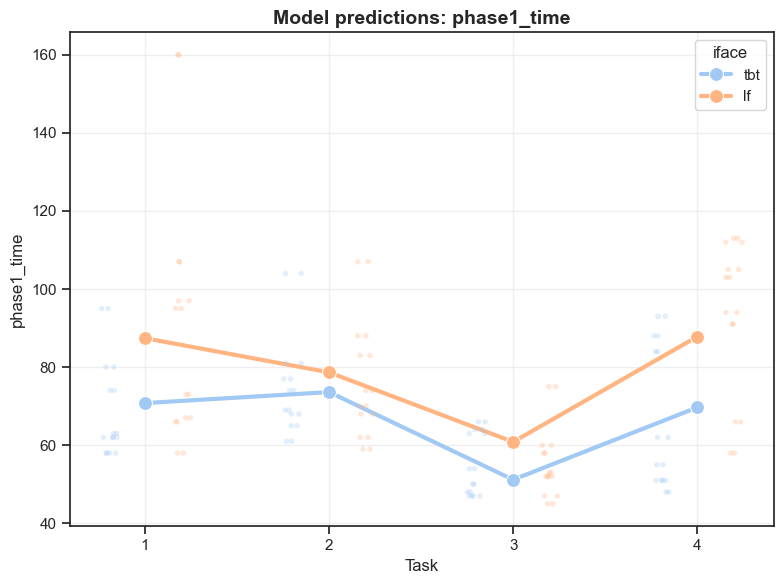

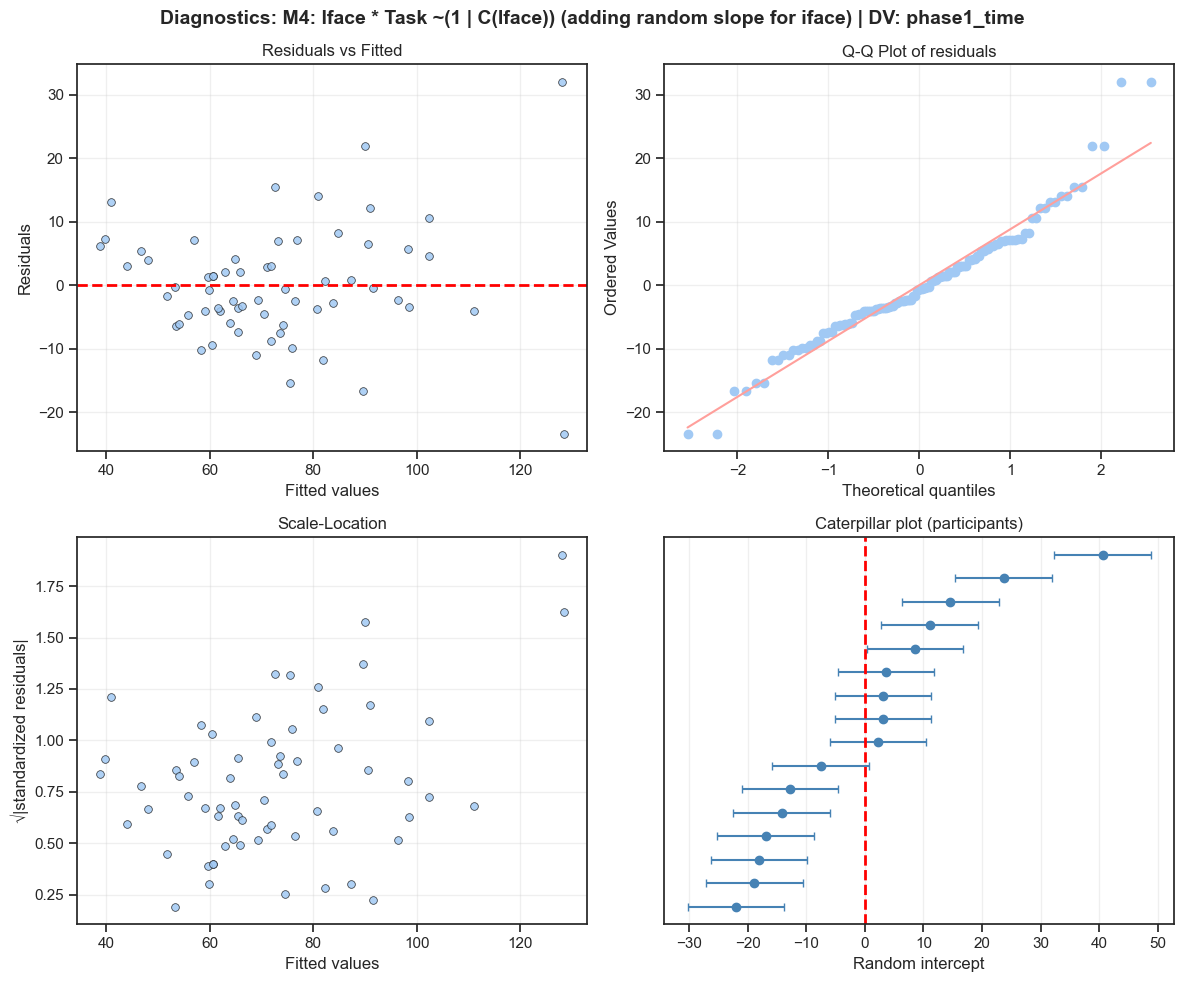


Analyzing: phase2_extra

Fitting models with ML (for comparison)...
  ✓ M1: Iface only ~1
  ✓ M2: Iface + Task ~1 (adding task)
  ✓ M3: Iface * Task ~1 (studying interaction)
  ✓ M4: Iface * Task ~(1 | C(Iface)) (adding random slope for iface)

Likelihood Ratio Tests (all comparisons)

M1 vs M2: Does task matter?
  LR χ²(3) = 7.54, p = 0.0565 ns

M2 vs M3: Is there interaction?
  LR χ²(3) = 10.03, p = 0.0183 *

M3 vs M4: Random slopes needed?
  LR χ²(2) = 15.36, p = 0.0005 ***

M1 vs M3: Does task+interaction matter?
  LR χ²(6) = 17.57, p = 0.0074 **

Model selection

✓ M1 vs M3 is significant (p=0.0074)
  → Interaction model (M3) is justified
  → M4 (random slopes) further improves fit

Selected: M4: Iface * Task ~(1 | C(Iface)) (adding random slope for iface)

Refitting selected model with REML for final estimates...

FINAL MODEL SUMMARY (REML)
                   Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      phase2_extra
No. Obs

/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


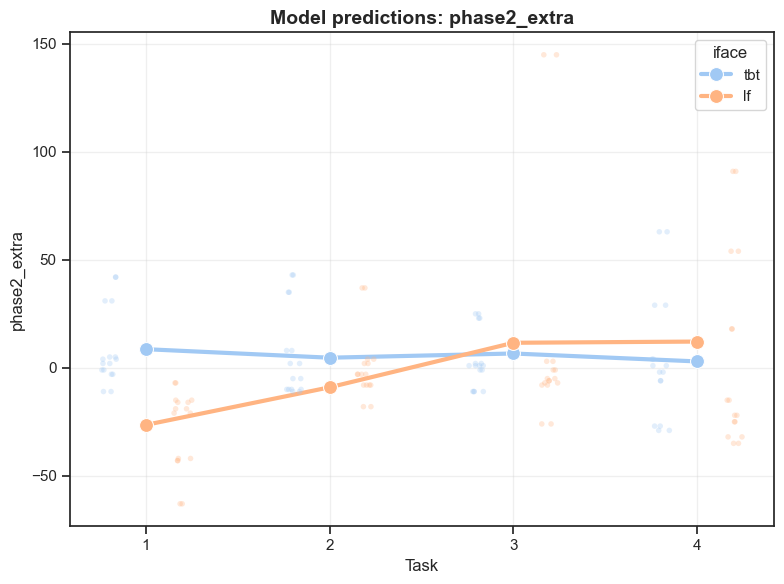

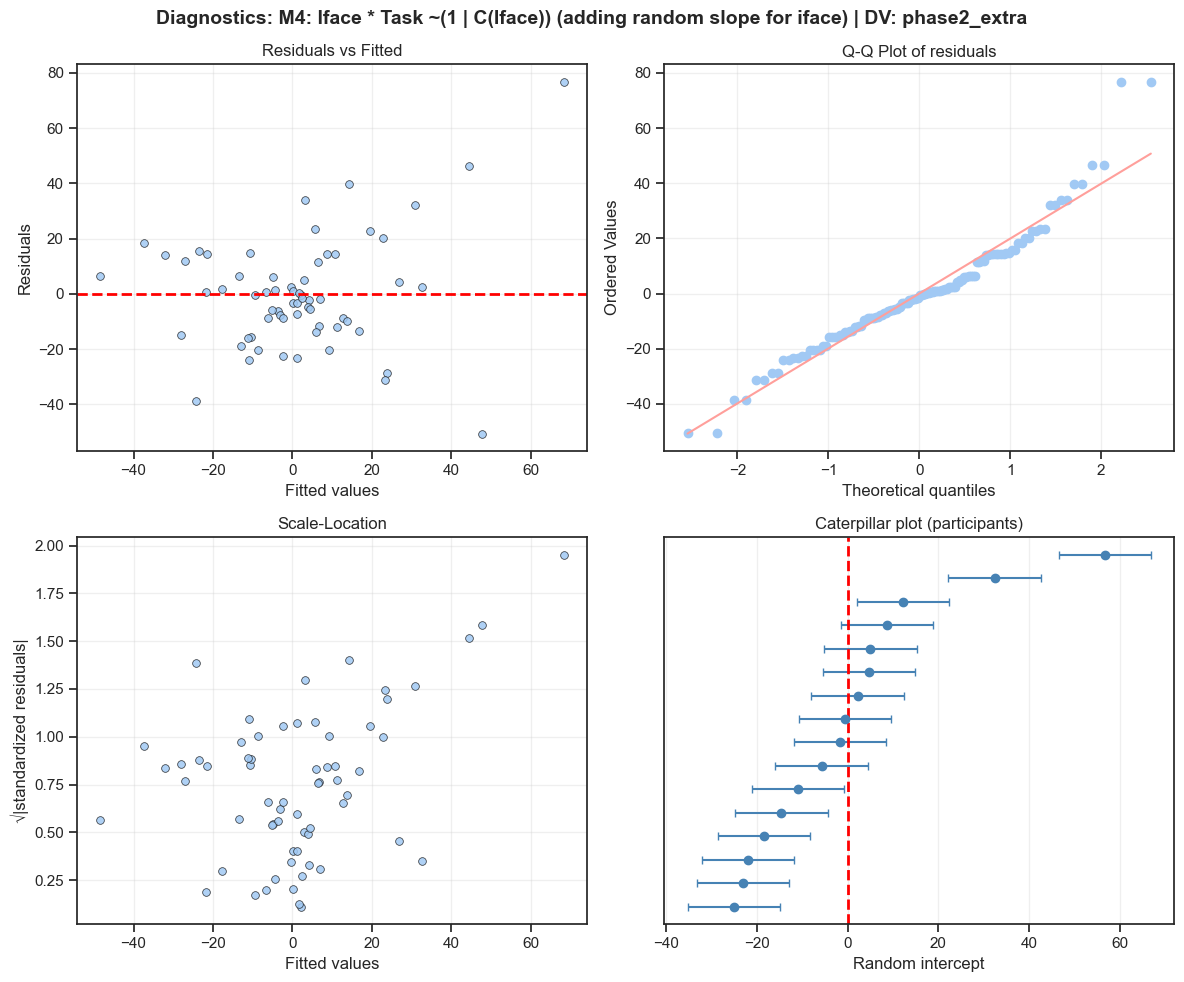


Analyzing: sketch_err

Fitting models with ML (for comparison)...
  ✓ M1: Iface only ~1
  ✓ M2: Iface + Task ~1 (adding task)
  ✓ M3: Iface * Task ~1 (studying interaction)
  ✓ M4: Iface * Task ~(1 | C(Iface)) (adding random slope for iface)

Likelihood Ratio Tests (all comparisons)

M1 vs M2: Does task matter?
  LR χ²(3) = 49.49, p = 0.0000 ***

M2 vs M3: Is there interaction?
  LR χ²(3) = 6.25, p = 0.1000 ns

M3 vs M4: Random slopes needed?
  LR χ²(2) = 5.95, p = 0.0509 ns

M1 vs M3: Does task+interaction matter?
  LR χ²(6) = 55.74, p = 0.0000 ***

Model selection

✓ M1 vs M3 is significant (p=0.0000)
  → Interaction model (M3) is justified
  → M3 is adequate (random slopes not needed)

Selected: M3: Iface * Task ~1 (studying interaction)

Refitting selected model with REML for final estimates...

FINAL MODEL SUMMARY (REML)
                   Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       sketch_err
No. Observations:         1

/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


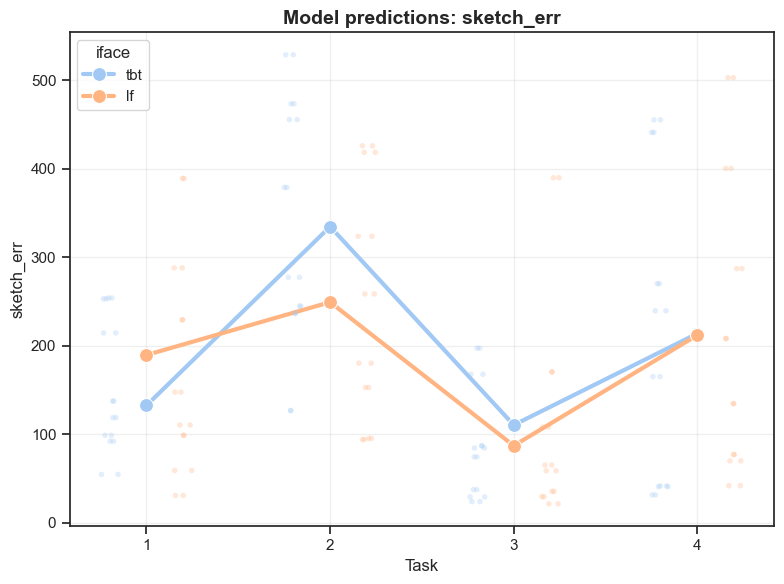

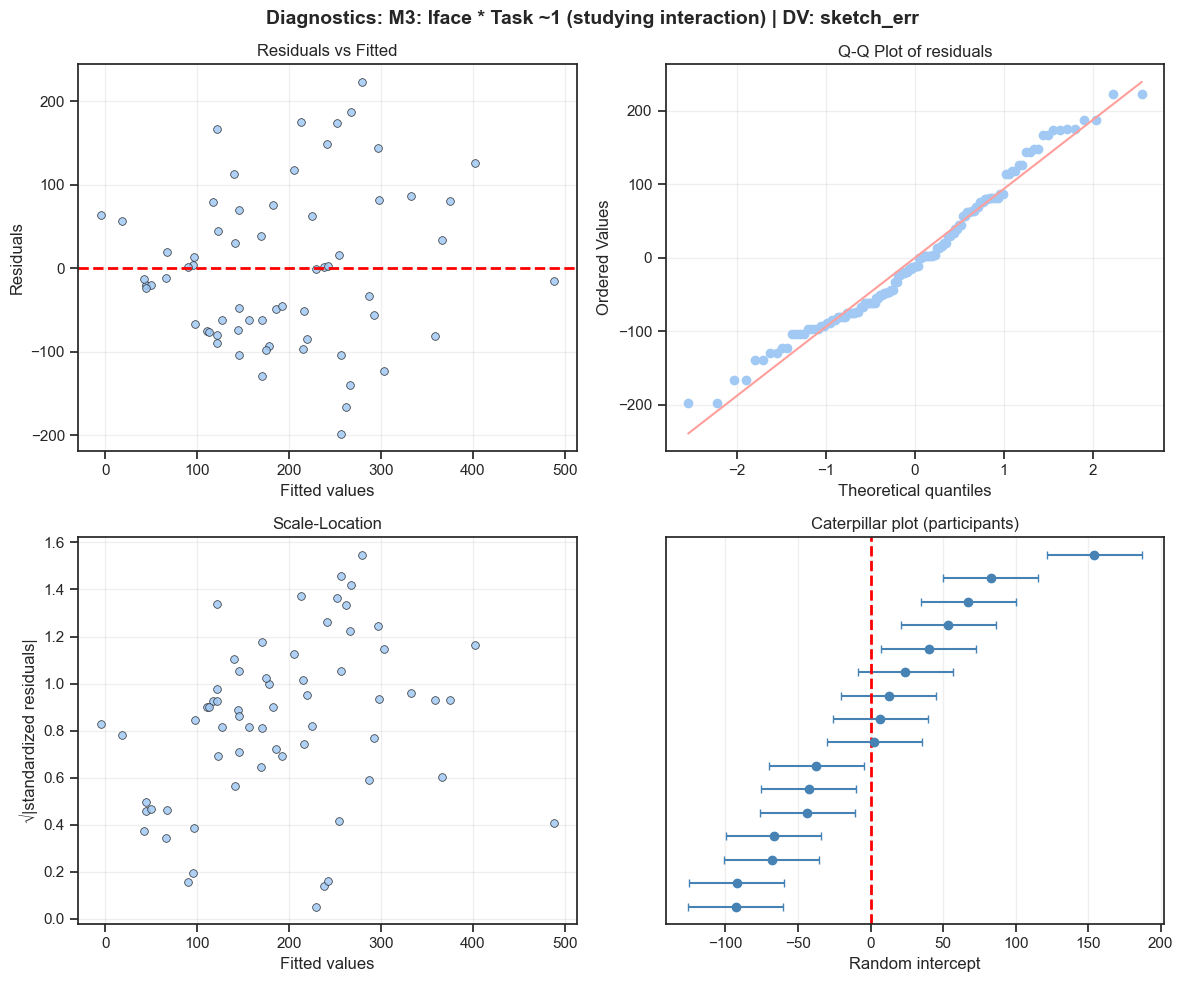


Analyzing: angle_time

Fitting models with ML (for comparison)...
  ✓ M1: Iface only ~1
  ✓ M2: Iface + Task ~1 (adding task)
  ✓ M3: Iface * Task ~1 (studying interaction)
  ✓ M4: Iface * Task ~(1 | C(Iface)) (adding random slope for iface)

Likelihood Ratio Tests (all comparisons)

M1 vs M2: Does task matter?
  LR χ²(3) = 5.97, p = 0.1132 ns

M2 vs M3: Is there interaction?
  LR χ²(3) = 2.51, p = 0.4738 ns

M3 vs M4: Random slopes needed?
  LR χ²(2) = -0.31, p = 1.0000 ns

M1 vs M3: Does task+interaction matter?
  LR χ²(6) = 8.48, p = 0.2053 ns

Model selection

✓ M1 (interface only) is adequate

Selected: M1: Iface only ~1

Refitting selected model with REML for final estimates...

FINAL MODEL SUMMARY (REML)
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: angle_time
No. Observations: 128     Method:             REML      
No. Groups:       16      Scale:              15.3056   
Min. group size:  8       Log-Likelihood:     -366.5481 
Max

/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


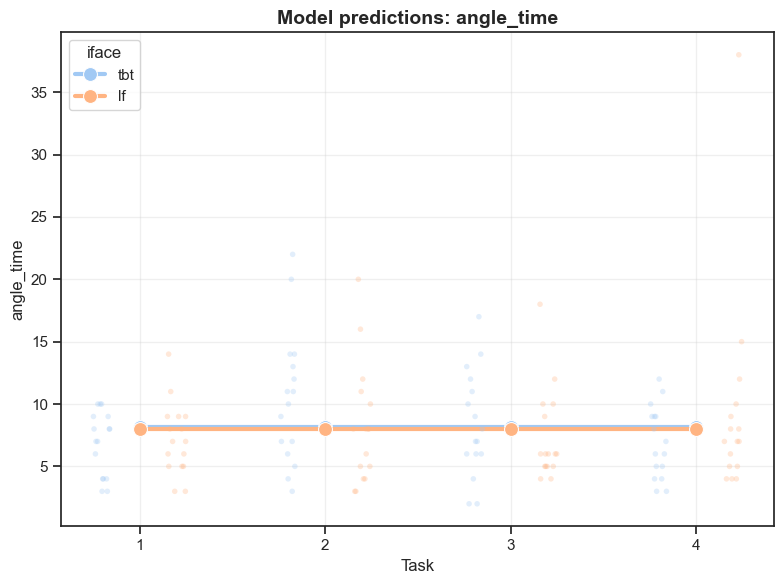

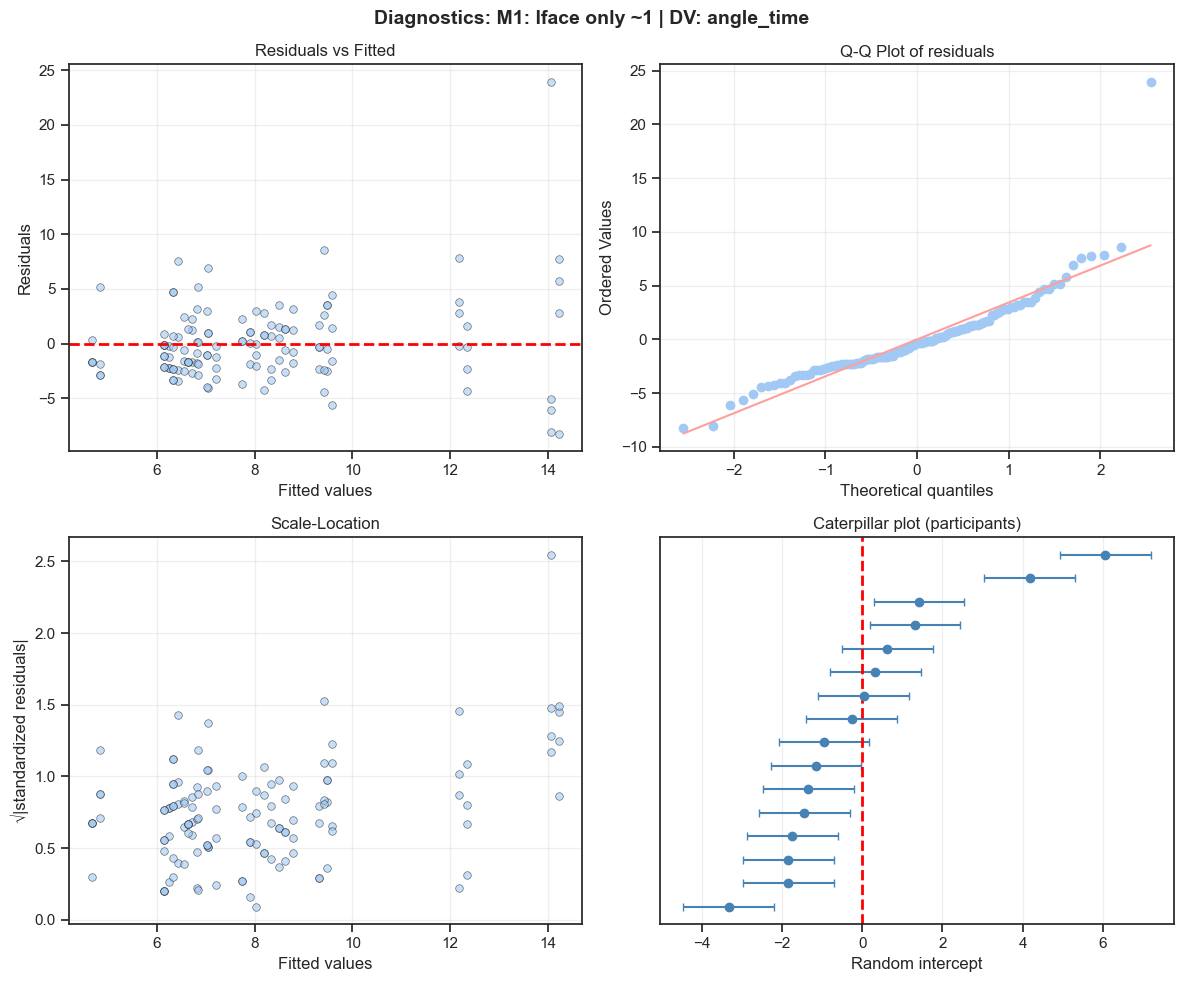


Analyzing: angle_err

Fitting models with ML (for comparison)...
  ✓ M1: Iface only ~1
  ✓ M2: Iface + Task ~1 (adding task)
  ✓ M3: Iface * Task ~1 (studying interaction)
  ✓ M4: Iface * Task ~(1 | C(Iface)) (adding random slope for iface)

Likelihood Ratio Tests (all comparisons)

M1 vs M2: Does task matter?
  LR χ²(3) = 23.05, p = 0.0000 ***

M2 vs M3: Is there interaction?
  LR χ²(3) = 2.63, p = 0.4516 ns

M3 vs M4: Random slopes needed?
  LR χ²(2) = 3.10, p = 0.2117 ns

M1 vs M3: Does task+interaction matter?
  LR χ²(6) = 25.69, p = 0.0003 ***

Model selection

✓ M1 vs M3 is significant (p=0.0003)
  → Interaction model (M3) is justified
  → M3 is adequate (random slopes not needed)

Selected: M3: Iface * Task ~1 (studying interaction)

Refitting selected model with REML for final estimates...

FINAL MODEL SUMMARY (REML)
                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       angle_err
No. Observations:       128     

/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


  Saved: plots/angle_err.png


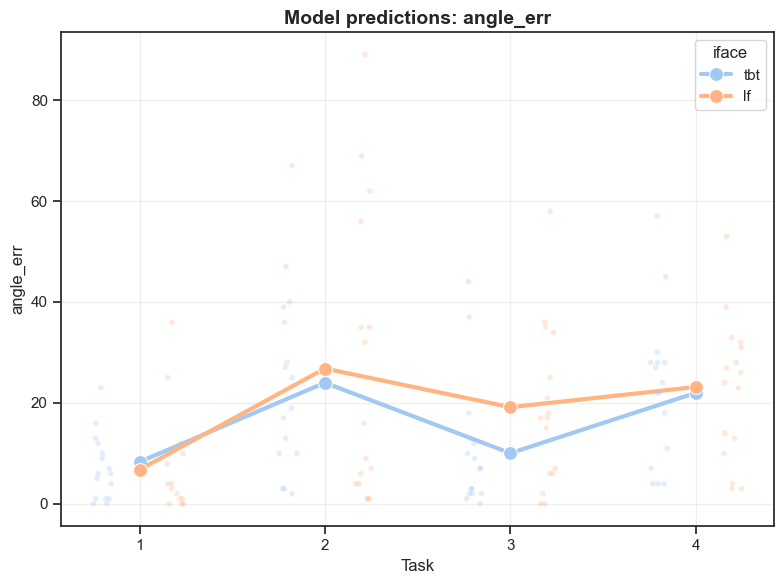

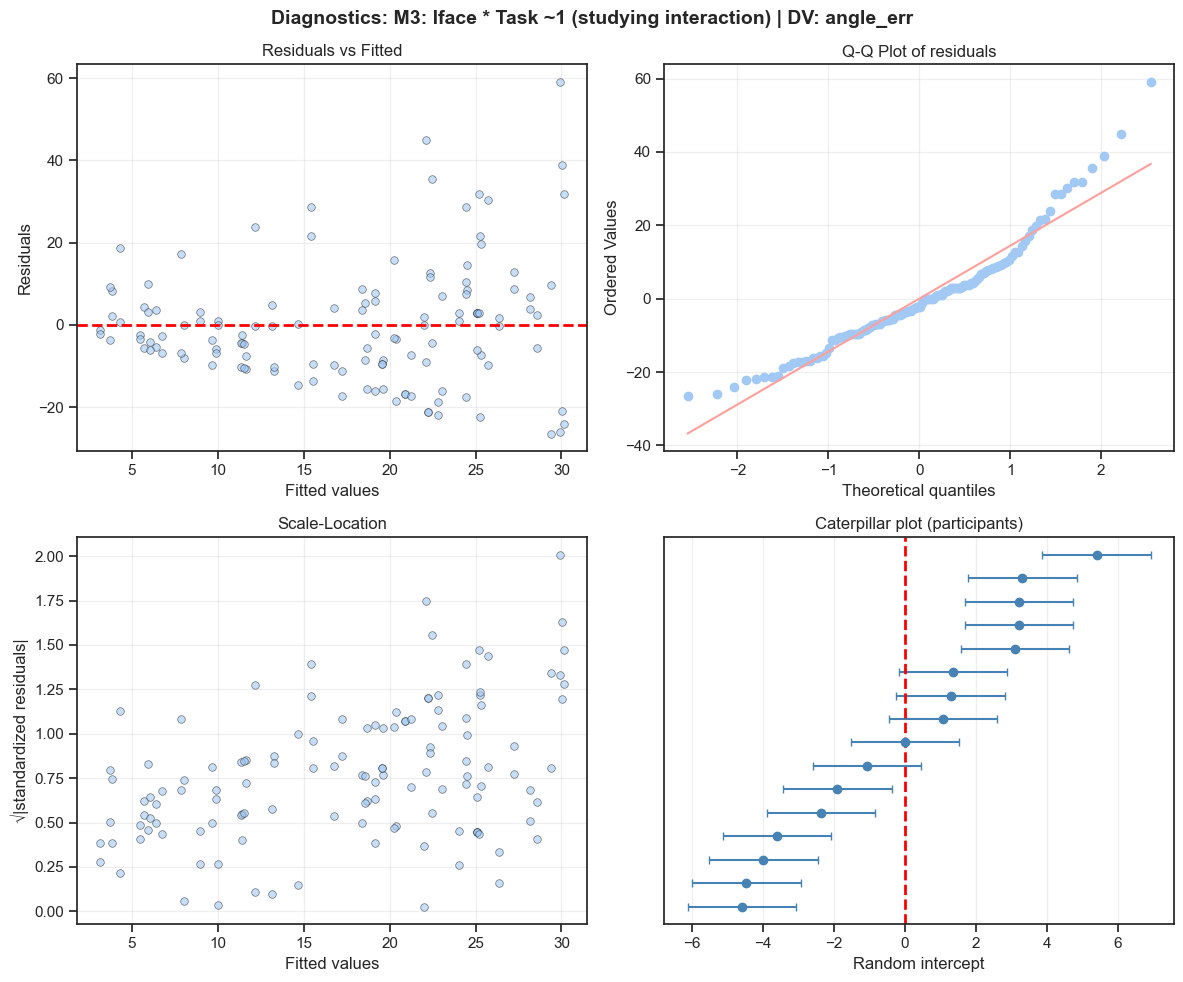

In [3]:
vars = ['phase1_time', 'phase2_extra', 'sketch_err', 'angle_time', 'angle_err']
all_results = {}
df = df_performance.reset_index()

for var in vars:
    all_results[var] = fit_model_hierarchy(df, var)
    
    predictions = plot_final_model(
        df, 
        all_results[var]['best_model'], 
        var,
        save_path=f'plots/{var}.png'
    )
    
    diagnostics = plot_diagnostics_final(all_results[var]['best_model'], var, all_results[var]['best_model_name'])
    diagnostics.savefig(f'plots/{var}_diagnostics.png', dpi=150, bbox_inches='tight')
    
    plt.show()


---

---

In [ ]:
# ============================================================================
# FUNCTION 2: Fit model hierarchy and select best via LRT
# ============================================================================

def fit_model_hierarchy(df, var):
    """
    Fit models in increasing complexity, use LRT to decide when to stop.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Your data with columns for participant, interface, task, and var
    var : str
        Name of dependent variable (e.g., 'phase1_time')
    
    Returns:
    --------
    dict with all fitted models and the selected best model
    """
    
    # Print header
    print(f"\n{'='*70}")
    print(f"Analyzing: {var}")
    print(f"{'='*70}\n")
    
    # Define the 4 models we'll test, in order of complexity
    models = [
        {
            'name': 'M1: Iface only ~1',
            'formula': f'{var} ~ C(iface)',
            're_formula': '~1'
        },
        {
            'name': 'M2: Iface + Task ~1 (adding task)',
            'formula': f'{var} ~ C(iface) + C(task)',
            're_formula': '~1'
        },
        {
            'name': 'M3: Iface + Task + AOI ~1 (adding aoi)',
            'formula': f'{var} ~ C(iface) + C(task) + C(AOI)',
            're_formula': '~1'
        },
        {
            'name': 'M4: Iface * Task * AOI ~1 (studying interaction)',
            'formula': f'{var} ~ C(iface) * C(task) * C(AOI)',
            're_formula': '~1'
        }
    ]
    
    fitted_models = []
    
    print("Fitting models with ML (for comparison)...")
    for spec in models:
        try:
            # Create the model object
            # groups= specifies which observations belong to same participant
            model = smf.mixedlm(
                spec['formula'],
                df,
                groups=df['name'],          # Grouping by participant
                re_formula=spec['re_formula'] # Random effects formula
            )
            
            # Fit the model
            # reml=False means use ML (for comparison)
            # method='lbfgs' is optimization algorithm (more robust)
            # maxiter=1000 gives it enough iterations to converge
            fitted = model.fit(reml=False, method='lbfgs', maxiter=1000)
            
            # Store the fitted model
            fitted_models.append({
                'name': spec['name'],
                'fitted': fitted,
                'formula': spec['formula'],
                're_formula': spec['re_formula'],
                'converged': fitted.converged
            })
            conv_status = "✓" if fitted.converged else "⚠"
            print(f"  {conv_status} {spec['name']}")
            
        except Exception as e:
            # If model fails to fit, print error and store None
            print(f"  ✗ {spec['name']} failed: {e}")
            fitted_models.append(None)
    
     # Compare ALL pairs
    print(f"\n{'='*70}")
    print("Likelihood Ratio Tests (all comparisons)")
    print(f"{'='*70}")
    
    comparisons = [
        (0, 1, "M1 vs M2: Does task matter?"),
        (1, 2, "M2 vs M3: Does AOI matter?"),
        (2, 3, "M3 vs M4: Interaction?"),
        (0, 2, "M1 vs M3: Does task+interaction+AOI matter?"),  # Direct comparison!
    ]
    
    lrt_results = []
    for idx_simple, idx_complex, description in comparisons:
        if fitted_models[idx_simple] is None or fitted_models[idx_complex] is None:
            continue
        
        simple = fitted_models[idx_simple]['fitted']
        complex = fitted_models[idx_complex]['fitted']
        
        lrt = likelihood_ratio_test(simple, complex)
        lrt_results.append({
            'comparison': description,
            'LR': lrt['LR'],
            'df': lrt['df'],
            'p': lrt['p'],
            'sig': lrt['sig']
        })
        
        print(f"\n{description}")
        print(f"  LR χ²({lrt['df']}) = {lrt['LR']:.2f}, p = {lrt['p']:.4f} {lrt['sig']}")
    
    # Decision logic: prioritize interaction test
    print(f"\n{'='*70}")
    print("Model selection")
    print(f"{'='*70}")
    
    # Check M1 vs M3 first (interaction)
    m1_vs_m3 = [r for r in lrt_results if 'M1 vs M3' in r['comparison']]
    if m1_vs_m3 and m1_vs_m3[0]['p'] < 0.05:
        print(f"\n✓ M1 vs M3 is significant (p={m1_vs_m3[0]['p']:.4f})")
        print(f"  → Interaction model (M3) is justified")
        
        # Check if M4 improves over M3
        m3_vs_m4 = [r for r in lrt_results if 'M3 vs M4' in r['comparison']]
        if m3_vs_m4 and m3_vs_m4[0]['p'] < 0.05:
            best_idx = 3
            print(f"  → M4 (random slopes) further improves fit")
        else:
            best_idx = 2
            print(f"  → M3 is adequate (random slopes not needed)")
    else:
        # Fall back to sequential logic
        m1_vs_m2 = [r for r in lrt_results if 'M1 vs M2' in r['comparison']]
        if m1_vs_m2 and m1_vs_m2[0]['p'] < 0.05:
            best_idx = 1
            print(f"\n✓ M2 (additive) is better than M1")
        else:
            best_idx = 0
            print(f"\n✓ M1 (interface only) is adequate")
    
    best = fitted_models[best_idx]
    print(f"\nSelected: {best['name']}")
    
    # Refit the selected model with REML for final parameter estimates
    # REML gives less biased variance estimates (but can't be used for comparison)
    print("\nRefitting selected model with REML for final estimates...")
    model_reml = smf.mixedlm(
        best['formula'], 
        df, 
        groups=df['name'],
        re_formula=best['re_formula']
    )
    # Now use reml=True for final fit
    final = model_reml.fit(reml=True, method='lbfgs', maxiter=1000)
    
    # Print the final model summary
    print("\n" + "="*70)
    print("FINAL MODEL SUMMARY (REML)")
    print("="*70)
    print(final.summary())
    
    # Return everything
    return {
        'all_models': fitted_models,       # All 4 models (for inspection)
        'best_model': final,               # Selected model with REML
        'best_model_name': best['name'],   # Name of selected model
        'lrt_results': lrt_results
    }

In [1]:
df_fixations

NameError: name 'df_fixations' is not defined


Analyzing: phase1_time

Fitting models with ML (for comparison)...
  ✓ M1: Iface only ~1
  ✓ M2: Iface + Task ~1 (adding task)
  ✓ M3: Iface * Task ~1 (studying interaction)
  ✓ M4: Iface * Task ~(1 | C(Iface)) (adding random slope for iface)

Likelihood Ratio Tests (all comparisons)

M1 vs M2: Does task matter?
  LR χ²(3) = 82.81, p = 0.0000 ***

M2 vs M3: Is there interaction?
  LR χ²(3) = 6.67, p = 0.0831 ns

M3 vs M4: Random slopes needed?
  LR χ²(2) = 12.10, p = 0.0024 **

M1 vs M3: Does task+interaction matter?
  LR χ²(6) = 89.48, p = 0.0000 ***

Model selection

✓ M1 vs M3 is significant (p=0.0000)
  → Interaction model (M3) is justified
  → M4 (random slopes) further improves fit

Selected: M4: Iface * Task ~(1 | C(Iface)) (adding random slope for iface)

Refitting selected model with REML for final estimates...

FINAL MODEL SUMMARY (REML)
                   Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       phase1_time
No. Ob

/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


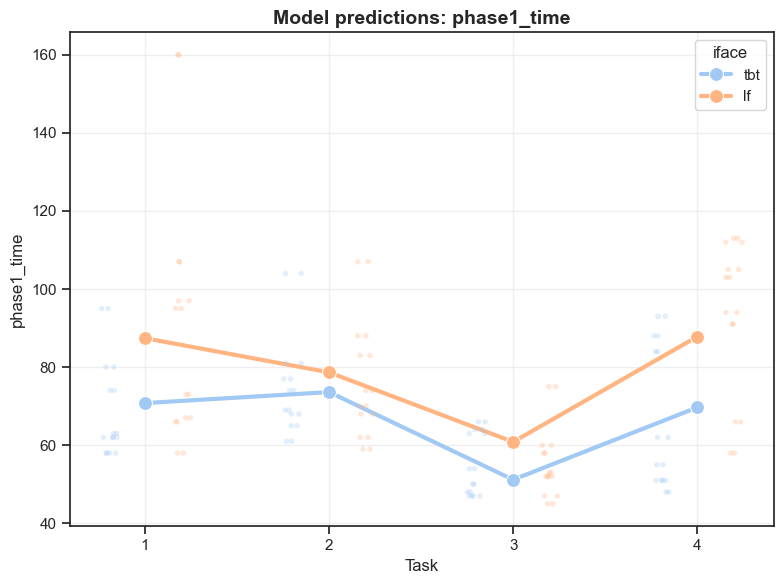

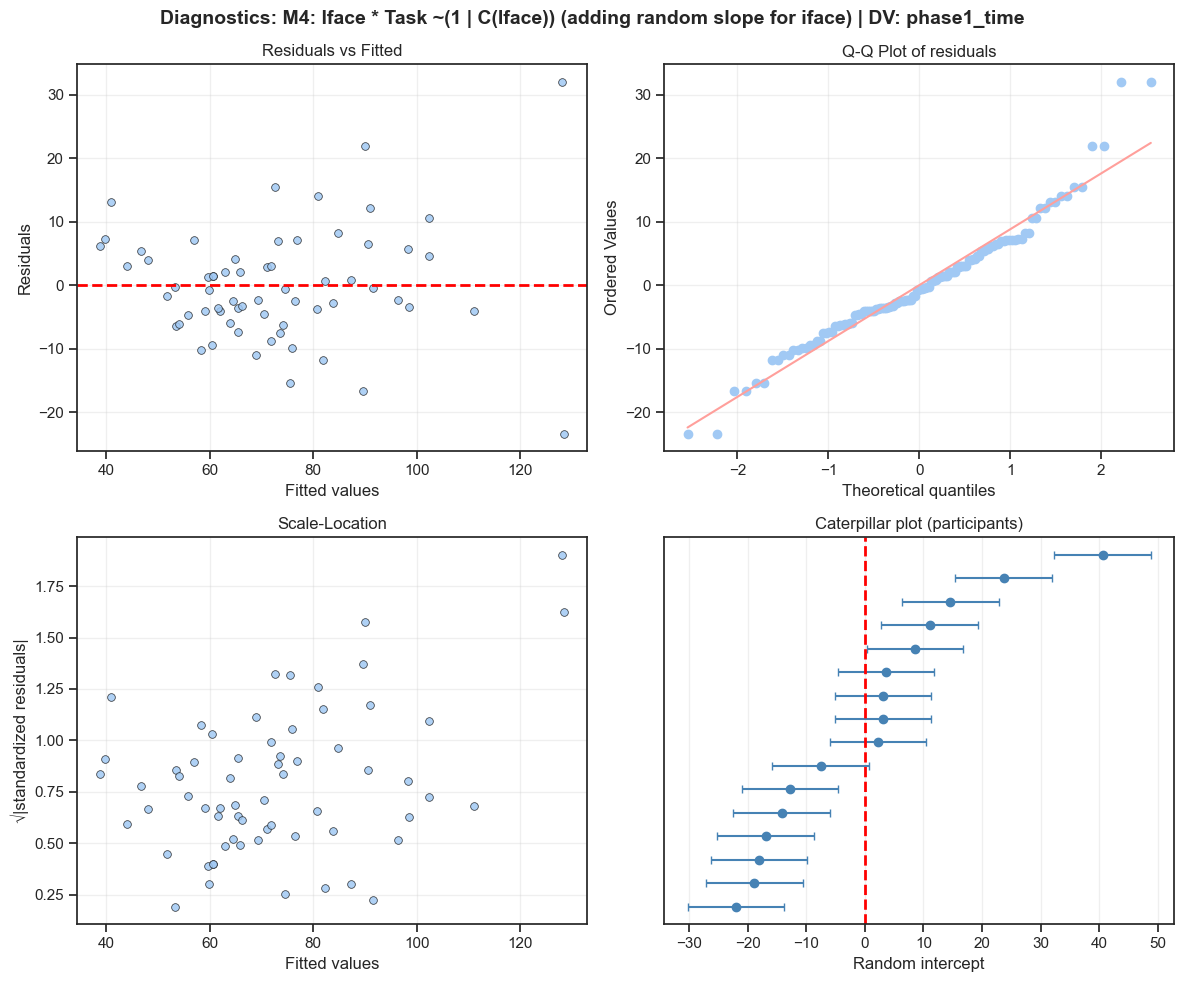


Analyzing: phase2_extra

Fitting models with ML (for comparison)...
  ✓ M1: Iface only ~1
  ✓ M2: Iface + Task ~1 (adding task)
  ✓ M3: Iface * Task ~1 (studying interaction)
  ✓ M4: Iface * Task ~(1 | C(Iface)) (adding random slope for iface)

Likelihood Ratio Tests (all comparisons)

M1 vs M2: Does task matter?
  LR χ²(3) = 7.54, p = 0.0565 ns

M2 vs M3: Is there interaction?
  LR χ²(3) = 10.03, p = 0.0183 *

M3 vs M4: Random slopes needed?
  LR χ²(2) = 15.36, p = 0.0005 ***

M1 vs M3: Does task+interaction matter?
  LR χ²(6) = 17.57, p = 0.0074 **

Model selection

✓ M1 vs M3 is significant (p=0.0074)
  → Interaction model (M3) is justified
  → M4 (random slopes) further improves fit

Selected: M4: Iface * Task ~(1 | C(Iface)) (adding random slope for iface)

Refitting selected model with REML for final estimates...

FINAL MODEL SUMMARY (REML)
                   Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      phase2_extra
No. Obs

/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


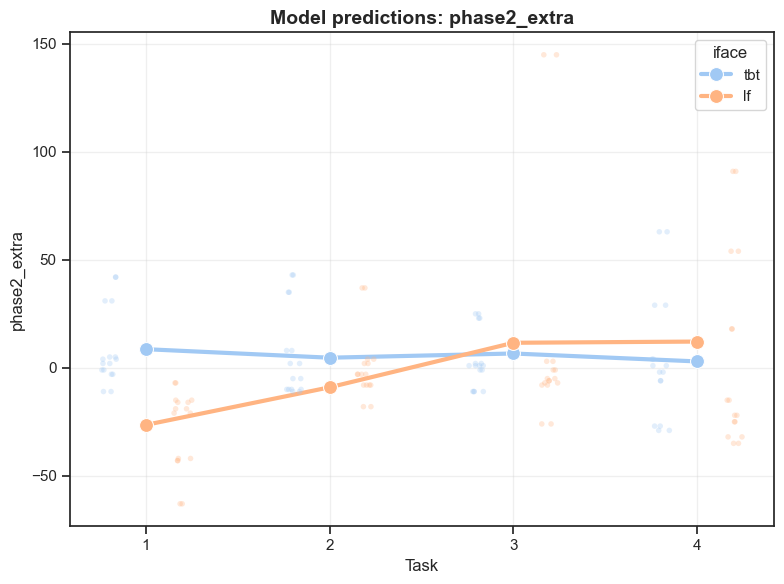

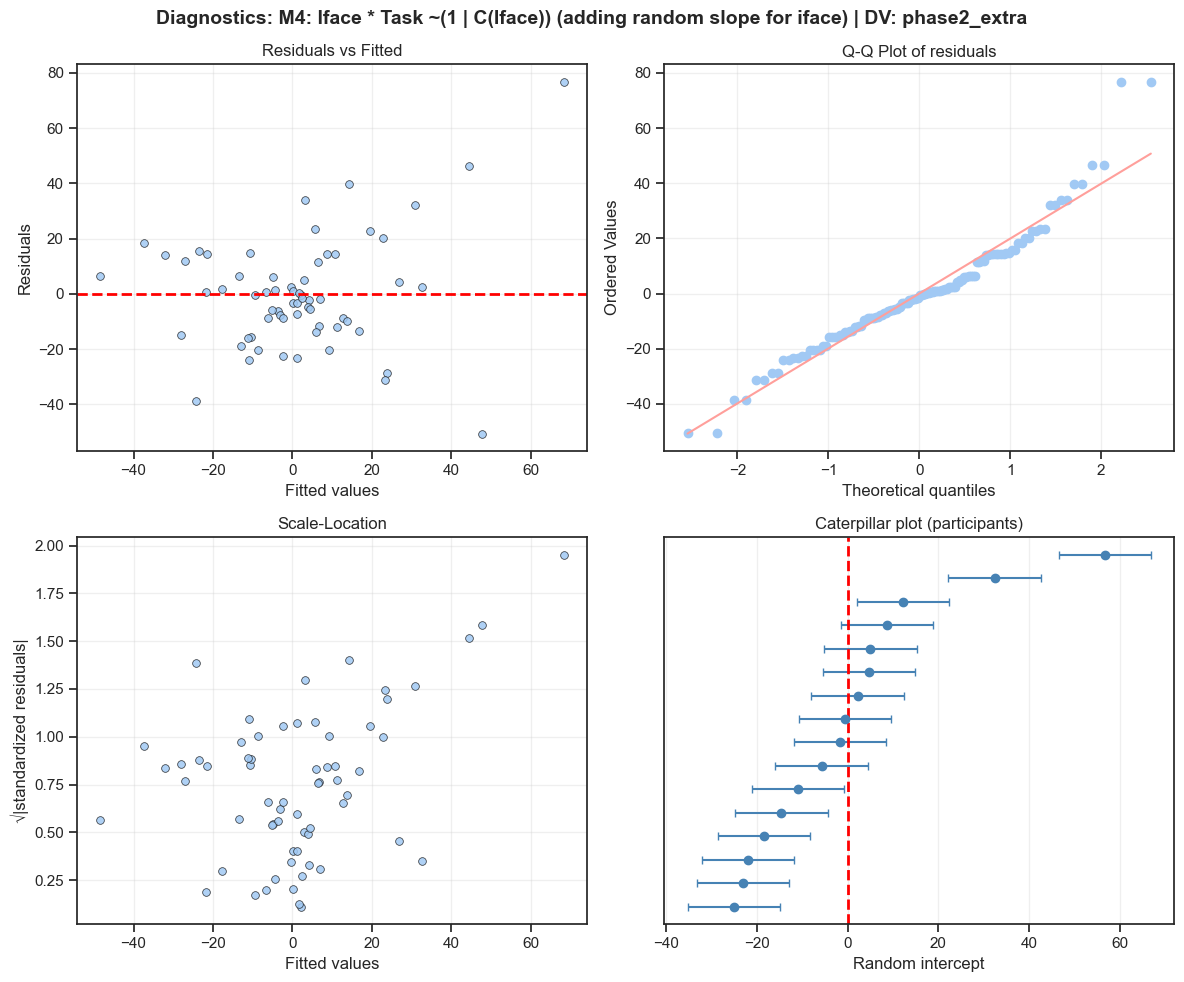


Analyzing: sketch_err

Fitting models with ML (for comparison)...
  ✓ M1: Iface only ~1
  ✓ M2: Iface + Task ~1 (adding task)
  ✓ M3: Iface * Task ~1 (studying interaction)
  ✓ M4: Iface * Task ~(1 | C(Iface)) (adding random slope for iface)

Likelihood Ratio Tests (all comparisons)

M1 vs M2: Does task matter?
  LR χ²(3) = 49.49, p = 0.0000 ***

M2 vs M3: Is there interaction?
  LR χ²(3) = 6.25, p = 0.1000 ns

M3 vs M4: Random slopes needed?
  LR χ²(2) = 5.95, p = 0.0509 ns

M1 vs M3: Does task+interaction matter?
  LR χ²(6) = 55.74, p = 0.0000 ***

Model selection

✓ M1 vs M3 is significant (p=0.0000)
  → Interaction model (M3) is justified
  → M3 is adequate (random slopes not needed)

Selected: M3: Iface * Task ~1 (studying interaction)

Refitting selected model with REML for final estimates...

FINAL MODEL SUMMARY (REML)
                   Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       sketch_err
No. Observations:         1

/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


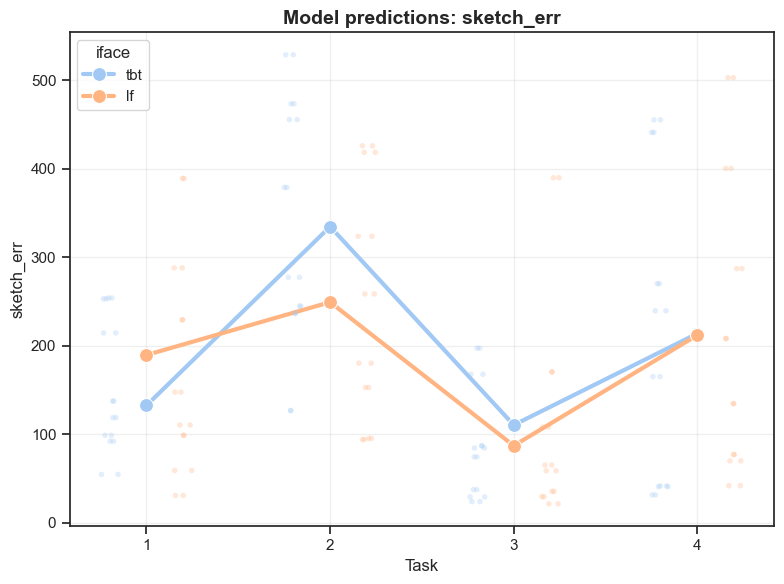

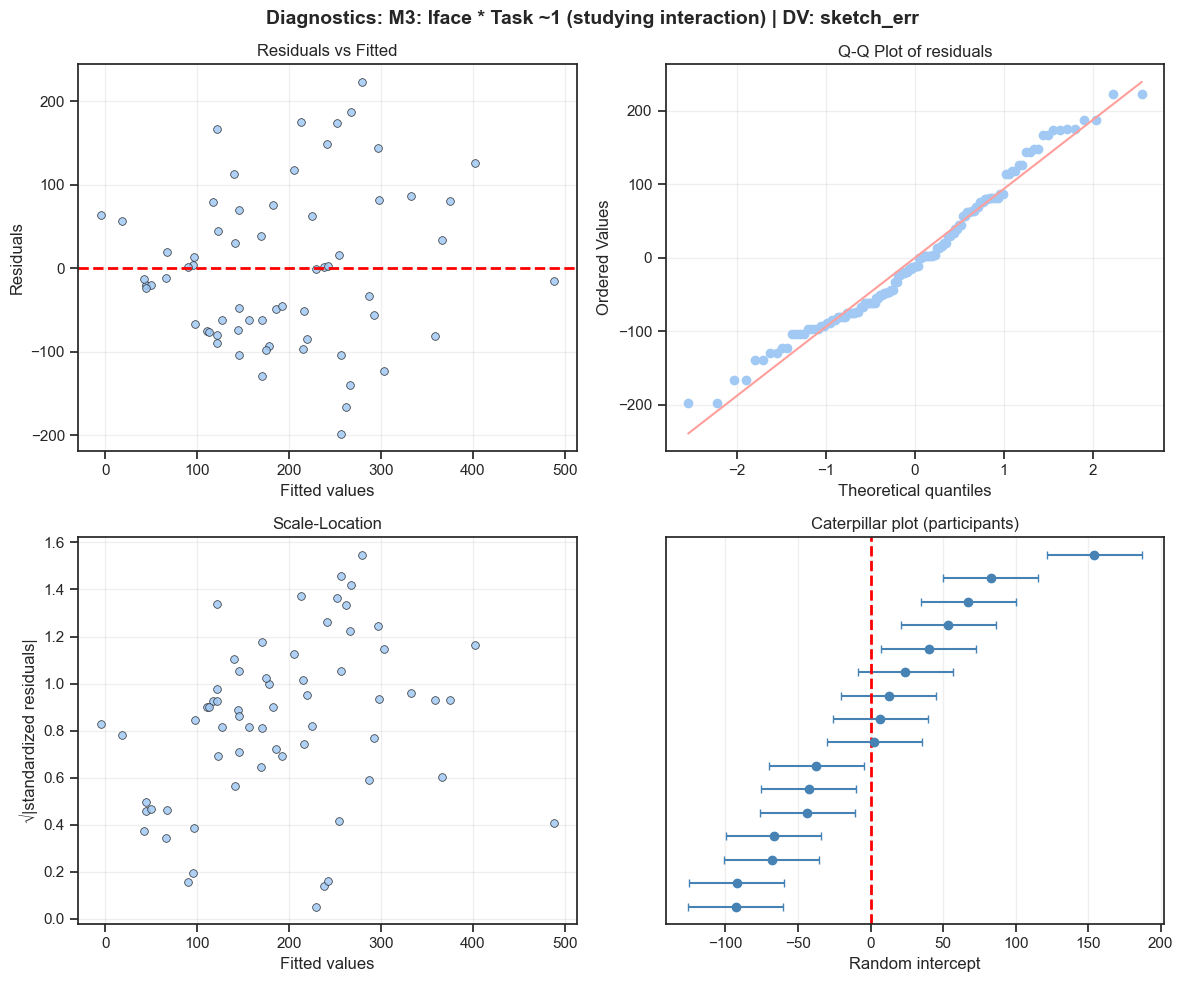


Analyzing: angle_time

Fitting models with ML (for comparison)...
  ✓ M1: Iface only ~1
  ✓ M2: Iface + Task ~1 (adding task)
  ✓ M3: Iface * Task ~1 (studying interaction)
  ✓ M4: Iface * Task ~(1 | C(Iface)) (adding random slope for iface)

Likelihood Ratio Tests (all comparisons)

M1 vs M2: Does task matter?
  LR χ²(3) = 5.97, p = 0.1132 ns

M2 vs M3: Is there interaction?
  LR χ²(3) = 2.51, p = 0.4738 ns

M3 vs M4: Random slopes needed?
  LR χ²(2) = -0.31, p = 1.0000 ns

M1 vs M3: Does task+interaction matter?
  LR χ²(6) = 8.48, p = 0.2053 ns

Model selection

✓ M1 (interface only) is adequate

Selected: M1: Iface only ~1

Refitting selected model with REML for final estimates...

FINAL MODEL SUMMARY (REML)
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: angle_time
No. Observations: 128     Method:             REML      
No. Groups:       16      Scale:              15.3056   
Min. group size:  8       Log-Likelihood:     -366.5481 
Max

/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


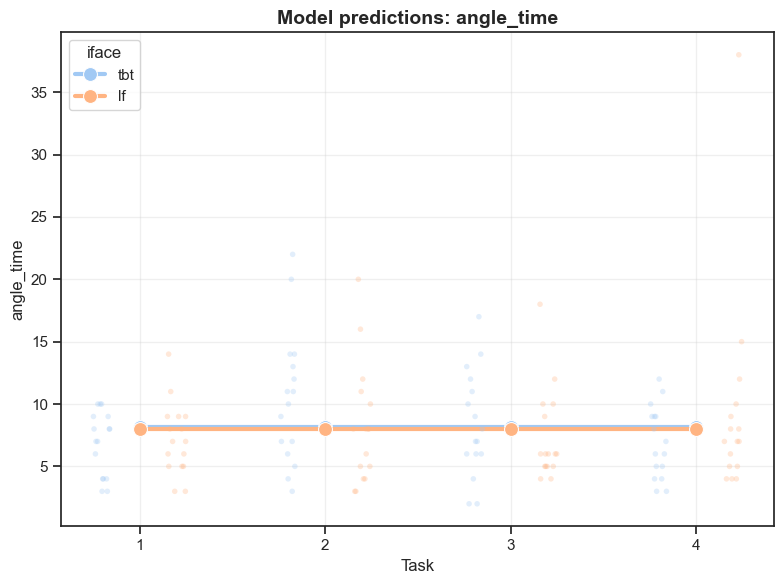

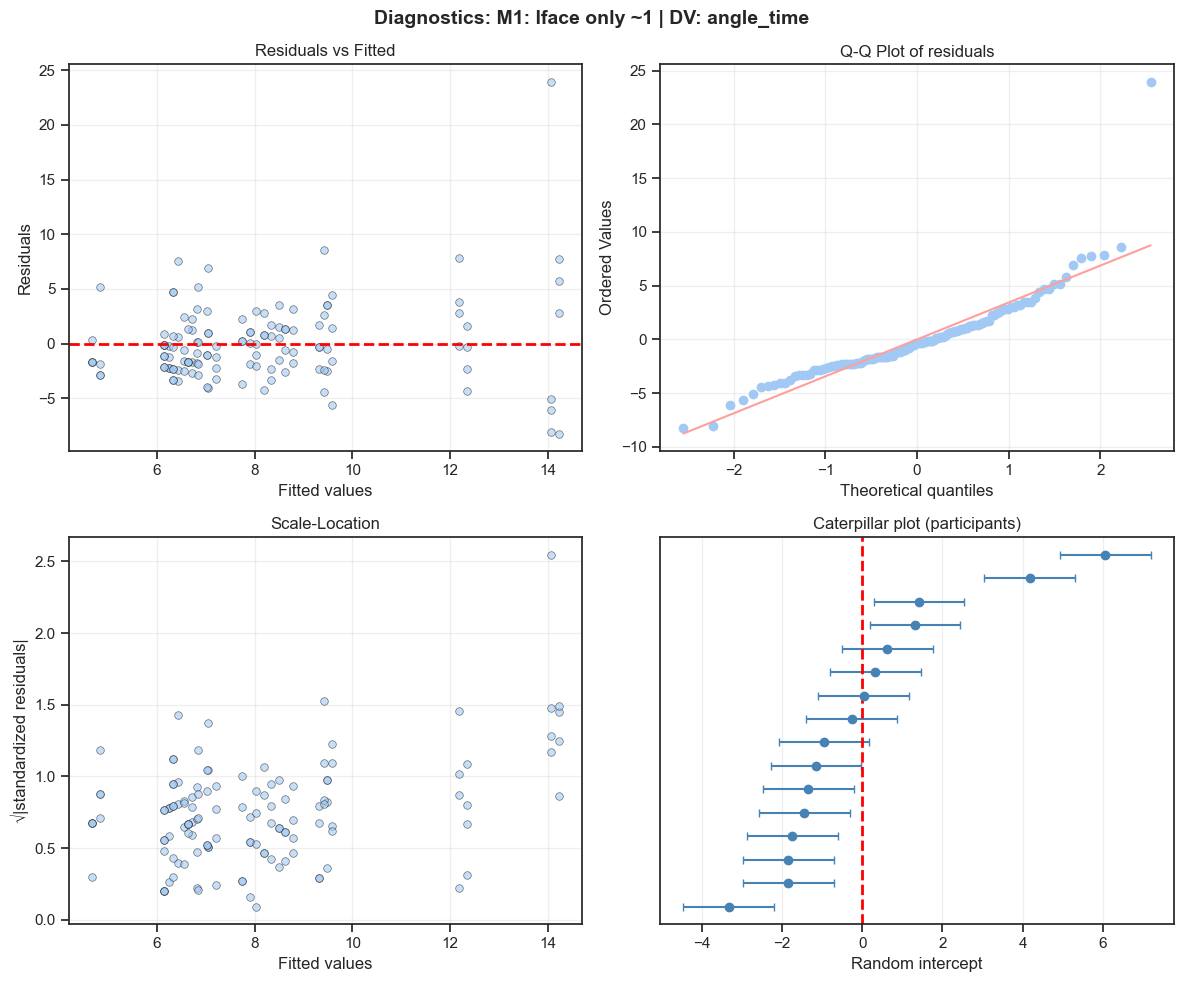


Analyzing: angle_err

Fitting models with ML (for comparison)...
  ✓ M1: Iface only ~1
  ✓ M2: Iface + Task ~1 (adding task)
  ✓ M3: Iface * Task ~1 (studying interaction)
  ✓ M4: Iface * Task ~(1 | C(Iface)) (adding random slope for iface)

Likelihood Ratio Tests (all comparisons)

M1 vs M2: Does task matter?
  LR χ²(3) = 23.05, p = 0.0000 ***

M2 vs M3: Is there interaction?
  LR χ²(3) = 2.63, p = 0.4516 ns

M3 vs M4: Random slopes needed?
  LR χ²(2) = 3.10, p = 0.2117 ns

M1 vs M3: Does task+interaction matter?
  LR χ²(6) = 25.69, p = 0.0003 ***

Model selection

✓ M1 vs M3 is significant (p=0.0003)
  → Interaction model (M3) is justified
  → M3 is adequate (random slopes not needed)

Selected: M3: Iface * Task ~1 (studying interaction)

Refitting selected model with REML for final estimates...

FINAL MODEL SUMMARY (REML)
                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       angle_err
No. Observations:       128     

/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/Users/andrea/Documents/vault/10. Projects/15. Master Thesis/analysis/myenv-thesis/lib/python3.13/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


  Saved: plots/angle_err.png


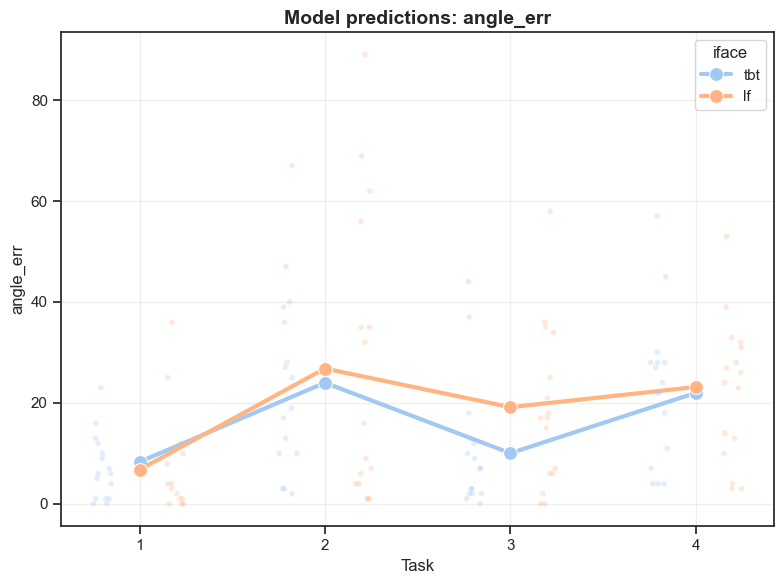

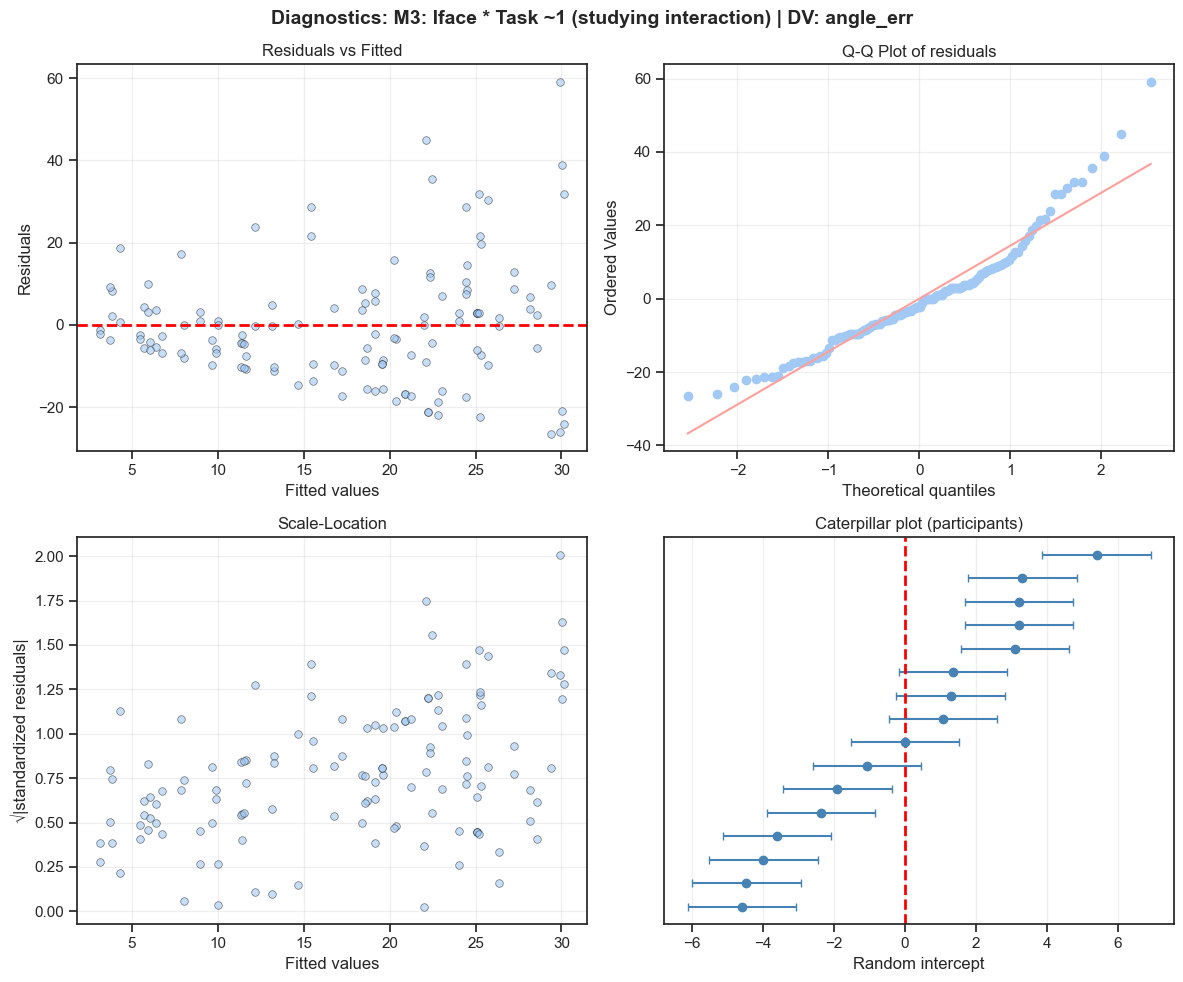

In [ ]:
vars = ['phase1_time', 'phase2_extra', 'sketch_err', 'angle_time', 'angle_err']
all_results = {}
df = df_performance.reset_index()

for var in vars:
    all_results[var] = fit_model_hierarchy(df, var)
    
    predictions = plot_final_model(
        df, 
        all_results[var]['best_model'], 
        var,
        save_path=f'plots/{var}.png'
    )
    
    diagnostics = plot_diagnostics_final(all_results[var]['best_model'], var, all_results[var]['best_model_name'])
    diagnostics.savefig(f'plots/{var}_diagnostics.png', dpi=150, bbox_inches='tight')
    
    plt.show()
